# Week 5 Task 1: Introduction to Machine Learning & Linear Regression

This notebook demonstrates the implementation of Linear Regression both from scratch using Gradient Descent and using the `scikit-learn` library.

## 1. Introduction to Machine Learning

Machine Learning is a field of study that gives computers the ability to learn without being explicitly programmed. In supervised learning (like Linear Regression), algorithms learn from labeled training data to make predictions on unseen data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Configure matplotlib for consistent plotting
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

## 2. Data Generation and Preprocessing

We will generate a synthetic dataset with a linear relationship: $y = 3X + 4 + noise$.

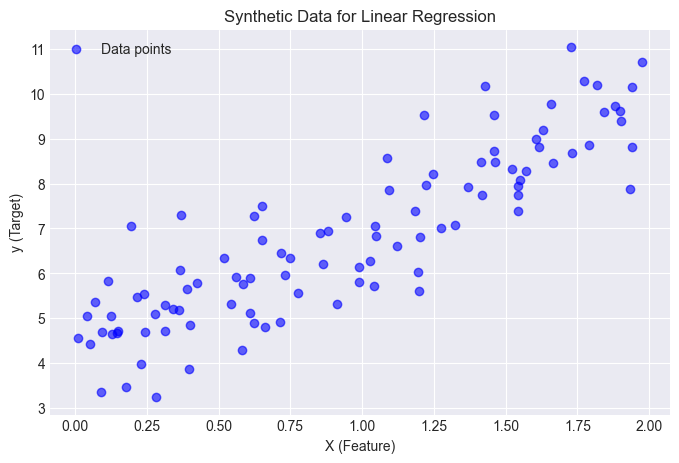

In [2]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate 100 random points for X between 0 and 2
X = 2 * np.random.rand(100, 1)

# Generate y with the true linear relationship y = 4 + 3x0 plus some Gaussian noise
y = 4 + 3 * X + np.random.randn(100, 1)

# Visualize the generated dataset
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.6, label='Data points')
plt.xlabel('X (Feature)')
plt.ylabel('y (Target)')
plt.title('Synthetic Data for Linear Regression')
plt.legend()
plt.show()

## 3. Linear Regression from Scratch using Gradient Descent

In this section, we implement the Gradient Descent algorithm to minimize the Cost Function (Mean Squared Error) and find the optimal parameters $\theta_0$ (intercept) and $\theta_1$ (slope).

### Cost Function (Mean Squared Error)
$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2$

In [3]:
def compute_cost(X, y, theta):
    """
    Compute the Mean Squared Error cost.
    X: Features (including bias column)
    y: Target values
    theta: Model parameters
    """
    m = len(y)
    predictions = X.dot(theta)
    error = predictions - y
    cost = (1/(2*m)) * np.sum(error**2)
    return cost

### Gradient Descent Algorithm
$\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta)$

In [4]:
def gradient_descent(X, y, theta, learning_rate, iterations):
    """
    Perform Gradient Descent to optimize parameters.
    """
    m = len(y)
    cost_history = np.zeros(iterations)
    theta_history = np.zeros((iterations, len(theta)))
    
    for i in range(iterations):
        predictions = X.dot(theta)
        error = predictions - y
        
        # Gradient calculation
        gradients = (1/m) * X.T.dot(error)
        
        # Update parameters
        theta = theta - learning_rate * gradients
        
        theta_history[i,:] = theta.T
        cost_history[i] = compute_cost(X, y, theta)
        
    return theta, cost_history, theta_history

### Training the Custom Model

Optimized Intercept (theta_0): 4.2151
Optimized Slope (theta_1): 2.7701


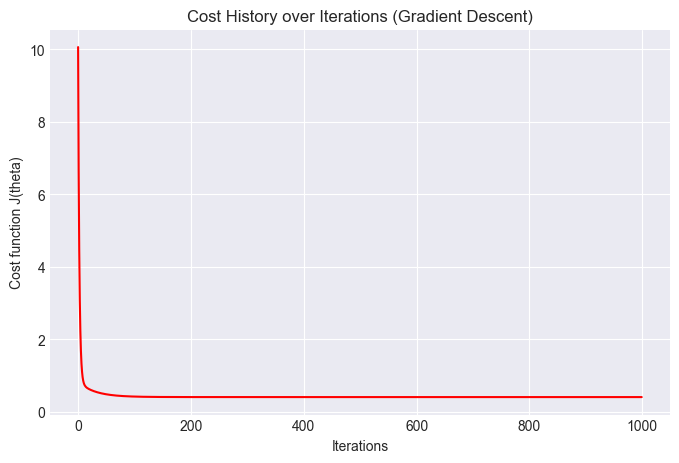

In [5]:
# Prepare the data: add a bias column (x_0 = 1) to X
X_b = np.c_[np.ones((100, 1)), X]

# Initialize parameters, learning rate, and iterations
theta_initial = np.random.randn(2, 1)  # random initialization
learning_rate = 0.1
iterations = 1000

# Run Gradient Descent
theta_optimal, cost_history, _ = gradient_descent(X_b, y, theta_initial, learning_rate, iterations)

print(f"Optimized Intercept (theta_0): {theta_optimal[0][0]:.4f}")
print(f"Optimized Slope (theta_1): {theta_optimal[1][0]:.4f}")

# Visualize Cost History
plt.figure(figsize=(8, 5))
plt.plot(range(iterations), cost_history, 'r-')
plt.xlabel('Iterations')
plt.ylabel('Cost function J(theta)')
plt.title('Cost History over Iterations (Gradient Descent)')
plt.show()

## 4. Linear Regression using Scikit-Learn

Now we will use the highly optimized `scikit-learn` library to perform the same task and compare the results.

In [6]:
# Initialize and train the model
lin_reg = LinearRegression()
lin_reg.fit(X, y)

print(f"Scikit-Learn Intercept: {lin_reg.intercept_[0]:.4f}")
print(f"Scikit-Learn Slope: {lin_reg.coef_[0][0]:.4f}")

Scikit-Learn Intercept: 4.2151
Scikit-Learn Slope: 2.7701


### Comparison and Visualization

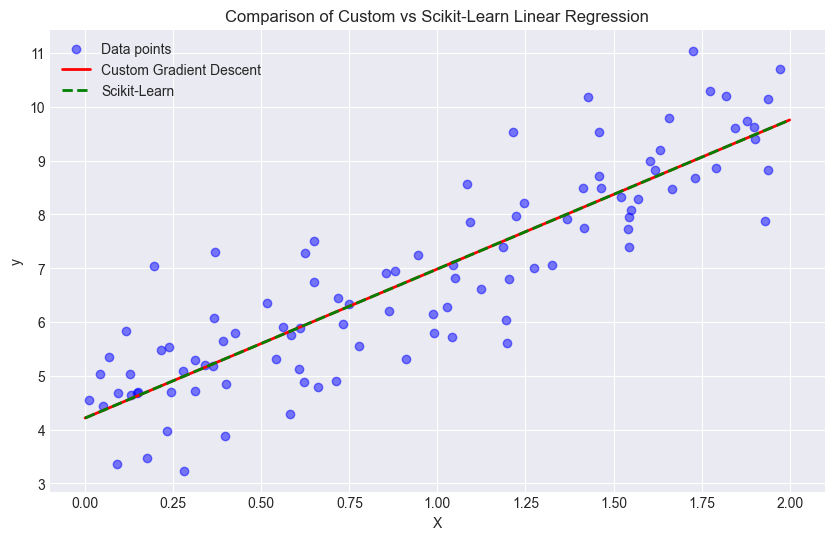

In [7]:
# Generate predictions for plotting the regression line
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]

# Custom model predictions
y_predict_custom = X_new_b.dot(theta_optimal)

# Scikit-learn predictions
y_predict_sklearn = lin_reg.predict(X_new)

# Plot both models
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.5, label='Data points')
plt.plot(X_new, y_predict_custom, 'r-', linewidth=2, label='Custom Gradient Descent')
plt.plot(X_new, y_predict_sklearn, 'g--', linewidth=2, label='Scikit-Learn')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Comparison of Custom vs Scikit-Learn Linear Regression')
plt.legend()
plt.show()

## Conclusion

Both implementations yield near-identical results. The intercept is close to 4, and the slope is close to 3, validating that our custom Gradient Descent algorithm works correctly and is equivalent to Scikit-Learn's Ordinary Least Squares approach for this dataset.